In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
path = r"C:\Users\SVS\Desktop\ML Project\data\ml_ready"
irrigation = pd.read_csv( path + r"\Crop_Irrigation_ML.csv")


In [3]:
print(irrigation.shape)


(9440, 14)


In [4]:
irrigation.columns

Index(['id', 'year', 'state_name', 'state_code', 'district_name',
       'district_code', 'food_category', 'crop_type', 'sub_crop_type',
       'crop_name', 'crop_code', 'season', 'area', 'old_district_name'],
      dtype='object')

In [5]:
irrigation.head()

,id,year,state_name,state_code,district_name,district_code,food_category,crop_type,sub_crop_type,crop_name,crop_code,season,area,old_district_name
0,379040,2014-2015,Telangana,36,Adilabad,501.0,Food Crop,Cereals & Millets,Cereals & Millets,Bajra,103.0,NaN,1479.0,Adilabad
1,379041,2014-2015,Telangana,36,Adilabad,501.0,Food Crop,Cereals & Millets,Cereals & Millets,Barley,107.0,NaN,NaN,Adilabad
2,379042,2014-2015,Telangana,36,Adilabad,501.0,Food Crop,Cereals & Millets,Cereals & Millets,Jowar,102.0,Kharif,0.0,Adilabad
3,379043,2014-2015,Telangana,36,Adilabad,501.0,Food Crop,Cereals & Millets,Cereals & Millets,Jowar,102.0,Rabi,3345.0,Adilabad
4,379044,2014-2015,Telangana,36,Adilabad,501.0,Food Crop,Cereals & Millets,Cereals & Millets,Jowar,102.0,Summer,NaN,Adilabad


In [6]:
irrigation.dtypes

id                     int64
year                  object
state_name            object
state_code             int64
district_name         object
district_code        float64
food_category         object
crop_type             object
sub_crop_type         object
crop_name             object
crop_code            float64
season                object
area                 float64
old_district_name     object
dtype: object

In [7]:
irrigation.isnull().sum()

id                      0
year                    0
state_name              0
state_code              0
district_name           0
district_code           0
food_category           0
crop_type               0
sub_crop_type           0
crop_name               0
crop_code               0
season               6372
area                 5371
old_district_name       0
dtype: int64

In [8]:
print( irrigation["season"].isnull().groupby(irrigation["area"].notnull())  .sum())

area
False    3532
True     2840
Name: season, dtype: int64


In [9]:
print(irrigation["crop_name"].unique())

['Bajra' 'Barley' 'Jowar' 'Maize' 'Other Cereals and Millets' 'Ragi'
 'Rice' 'Wheat' 'Other Food Crops' 'Arhar(Tur)' 'Gram' 'Other Pulses'
 'Sugarcane' 'Coffee' 'Other Plantation Crops' 'Tea' 'Tobacco' 'Cotton'
 'Jute' 'Mesta' 'Other Fibres' 'Sanhemp' 'Fodder Crops' 'Groundnut'
 'Linseed' 'Other Oilseeds' 'Rapeseed and Mustard' 'Sesamum' 'Soyabean'
 'Sunflower' 'Other Non Food Crops']


In [10]:
crop_season = {
    "Bajra": "Kharif",
    "Barley": "Rabi",
    "Jowar": "Rabi",
    "Maize": "Kharif",
    "Other Cereals and Millets": "Kharif",
    "Ragi": "Kharif",
    "Rice": "Kharif",
    "Wheat": "Rabi",

    "Other Food Crops": "Kharif",
    "Arhar(Tur)": "Kharif",
    "Gram": "Rabi",
    "Other Pulses": "Kharif",

    "Sugarcane": "Kharif",
    "Coffee": "Kharif",
    "Other Plantation Crops": "Kharif",
    "Tea": "Kharif",
    "Tobacco": "Rabi",

    "Cotton": "Kharif",
    "Jute": "Kharif",
    "Mesta": "Kharif",
    "Other Fibres": "Kharif",
    "Sanhemp": "Kharif",
    "Fodder Crops": "Kharif",

    "Groundnut": "Kharif",
    "Linseed": "Rabi",
    "Other Oilseeds": "Kharif",
    "Rapeseed and Mustard": "Rabi",
    "Sesamum": "Kharif",
    "Soyabean": "Kharif",
    "Sunflower": "Rabi",
    "Other Non Food Crops": "Kharif"
}

In [11]:
#  District + Crop + Year
season_map = (
    irrigation.dropna(subset=["season"])
    .groupby(
        ["old_district_name", "crop_name", "year"]
    )["season"]
    .agg(lambda x: x.mode().iloc[0])
)

keys = pd.MultiIndex.from_frame(
    irrigation[
        ["old_district_name", "crop_name", "year"]
    ]
)

season_values = pd.Series(
    season_map.reindex(keys).values,
    index=irrigation.index
)

irrigation["season"] = irrigation["season"].fillna(
    season_values
)


# STEP 2: Crop-based fallback
irrigation["season"] = irrigation["season"].fillna(
    irrigation["crop_name"].map(crop_season)
)


# FINAL CHECK
print("Remaining season nulls:",
      irrigation["season"].isnull().sum())

print("\nSeason counts:")
print(irrigation["season"].value_counts())

Remaining season nulls: 0

Season counts:
season
Kharif    5664
Rabi      2360
Summer     944
Autumn     236
Winter     236
Name: count, dtype: int64


In [12]:
irrigation.isnull().sum()

id                      0
year                    0
state_name              0
state_code              0
district_name           0
district_code           0
food_category           0
crop_type               0
sub_crop_type           0
crop_name               0
crop_code               0
season                  0
area                 5371
old_district_name       0
dtype: int64

In [13]:
irrigation = irrigation.sort_values(
    ["district_name", "crop_name", "season", "year"]
)

irrigation["area"] = (
    irrigation.groupby(
        ["district_name", "crop_name", "season"]
    )["area"]
    .ffill()
    .bfill()
)

print("Remaining area nulls:",
      irrigation["area"].isnull().sum())

Remaining area nulls: 0


In [14]:
irrigation.isnull().sum()

id                   0
year                 0
state_name           0
state_code           0
district_name        0
district_code        0
food_category        0
crop_type            0
sub_crop_type        0
crop_name            0
crop_code            0
season               0
area                 0
old_district_name    0
dtype: int64

In [17]:
irrigation["year_start"] = (
    irrigation["year"]
    .astype(str)
    .str[:4]
    .astype(int)
)

In [21]:
## Outliers 
Q1 = irrigation["area"].quantile(0.25)
Q3 = irrigation["area"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Q1: 2.0
Q3: 981.5
IQR: 979.5
Lower limit: -1467.25
Upper limit: 2450.75


In [22]:
outliers = irrigation[
    (irrigation["area"] < lower_limit) |
    (irrigation["area"] > upper_limit)
]

print("Number of outliers:", len(outliers))

Number of outliers: 1926


## Feature Engineering

In [23]:
irrigation["year_start"] = (
    irrigation["year"]
    .astype(str)
    .str[:4]
    .astype(int)
)

In [24]:
## Previous Year Integrated area
irrigation = irrigation.sort_values(
    [
        "district_name",
        "crop_name",
        "year_start"
    ]
)

In [25]:
irrigation["previous_year_area"] = (
    irrigation.groupby(
        ["district_name", "crop_name"]
    )["area"]
    .shift(1)
)

In [26]:
## Historical average irrigated area
irrigation["historical_avg_area"] = (
    irrigation.groupby(
        ["district_name", "crop_name"]
    )["area"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

In [27]:
## Change from previous year
irrigation["area_change"] = (
    irrigation["area"]
    - irrigation["previous_year_area"]
)

In [28]:
irrigation.isnull().sum()

id                       0
year                     0
state_name               0
state_code               0
district_name            0
district_code            0
food_category            0
crop_type                0
sub_crop_type            0
crop_name                0
crop_code                0
season                   0
area                     0
old_district_name        0
year_start               0
previous_year_area     992
historical_avg_area    992
area_change            992
dtype: int64

## Univariate Analysis 

In [30]:
# Crop distribution
print(irrigation["crop_name"].value_counts())

crop_name
Rice                         944
Jowar                        708
Other Cereals and Millets    708
Other Pulses                 708
Arhar(Tur)                   236
Other Oilseeds               236
Tobacco                      236
Tea                          236
Sunflower                    236
Sugarcane                    236
Soyabean                     236
Sesamum                      236
Sanhemp                      236
Rapeseed and Mustard         236
Ragi                         236
Other Plantation Crops       236
Other Food Crops             236
Other Non Food Crops         236
Bajra                        236
Other Fibres                 236
Mesta                        236
Maize                        236
Linseed                      236
Jute                         236
Groundnut                    236
Gram                         236
Fodder Crops                 236
Cotton                       236
Coffee                       236
Barley                       236


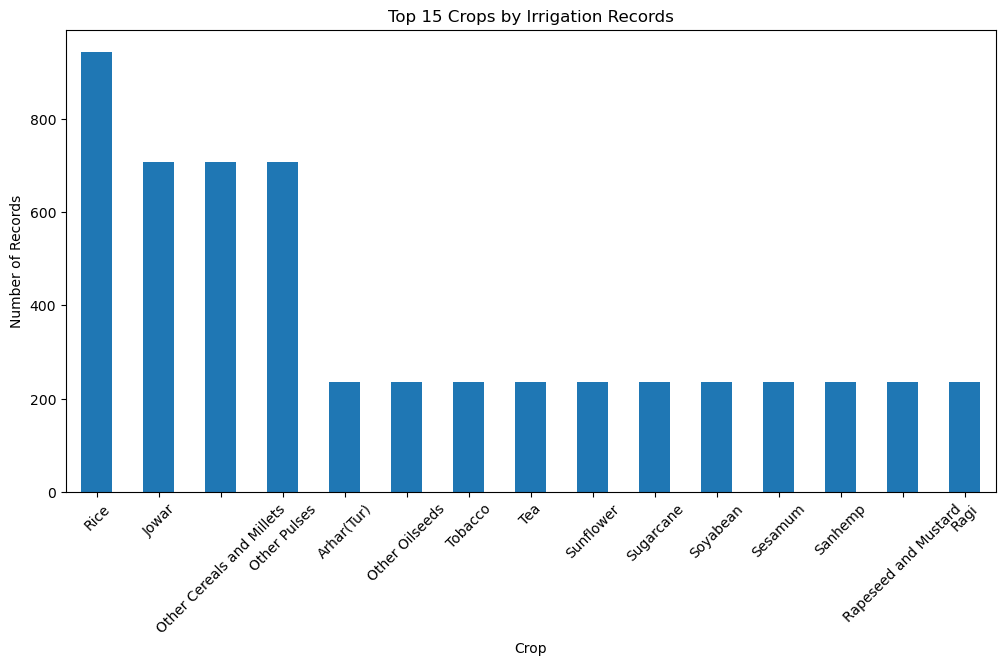

In [31]:
plt.figure(figsize=(12, 6))

irrigation["crop_name"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top 15 Crops by Irrigation Records")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

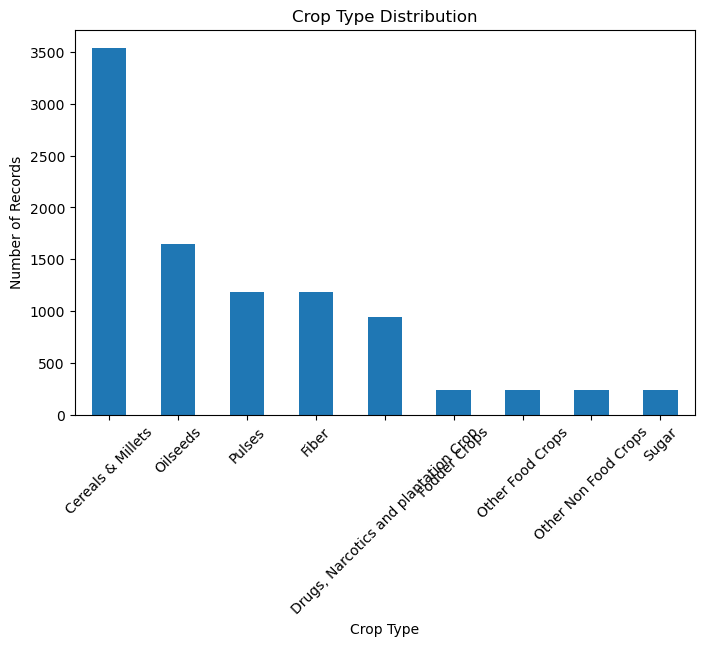

In [32]:
## Crop Type Distribution
plt.figure(figsize=(8, 5))

irrigation["crop_type"].value_counts().plot(
    kind="bar"
)

plt.title("Crop Type Distribution")
plt.xlabel("Crop Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [33]:
# Season distribution
print(irrigation["season"].value_counts(dropna=False))

season
Kharif    5664
Rabi      2360
Summer     944
Autumn     236
Winter     236
Name: count, dtype: int64


In [34]:
# District distribution
print(irrigation["district_name"].value_counts())

district_name
Adilabad                    360
Nalgonda                    360
Nizamabad                   360
Medak                       360
Mahabubnagar                360
Ranga Reddy                 360
Khammam                     360
Karimnagar                  360
Warangal                    360
Sangareddy                  280
Siddipet                    280
Suryapet                    280
Rajanna Sircilla            280
Vikarabad                   280
Peddapalli                  280
Wanaparthy                  280
Nirmal                      280
Yadadri Bhuvanagiri         280
Nagarkurnool                280
Bhadradri Kothagudem        280
Medchal Malkajgiri          280
Mancherial                  280
Mahabubabad                 280
Kumuram Bheem Asifabad      280
Kamareddy                   280
Jogulamba Gadwal            280
Jayashankar Bhupalapally    280
Jangoan                     280
Jagitial                    280
Hanumakonda                 280
Narayanpet                

In [35]:
# Year distribution
print(irrigation["year"].value_counts().sort_index())

year
2014-2015     360
2015-2016     360
2016-2017    1200
2017-2018    1200
2018-2019    1200
2019-2020    1280
2020-2021    1280
2021-2022    1280
2022-2023    1280
Name: count, dtype: int64


In [36]:
print(irrigation["area"].describe())

count      9440.000000
mean       6681.652436
std       20575.952438
min           0.000000
25%           2.000000
50%          26.000000
75%         981.500000
max      225262.000000
Name: area, dtype: float64


## Bivariate Analysis 

In [38]:
## District vs Area
district_area = (
    irrigation.groupby("district_name")["area"]
    .mean()
    .sort_values(ascending=False)
)

print(district_area)

district_name
Suryapet                    14372.760714
Karimnagar                  11990.575000
Nizamabad                   11673.675000
Warangal                    11321.400000
Nalgonda                    11283.605556
Jagitial                    11132.867857
Khammam                      9508.344444
Kamareddy                    8365.189286
Peddapalli                   7779.253571
Siddipet                     7597.639286
Mancherial                   6641.035714
Nirmal                       6554.482143
Mahabubabad                  6553.478571
Nagarkurnool                 6131.742857
Jayashankar Bhupalapally     6114.360714
Hanumakonda                  5961.642857
Yadadri Bhuvanagiri          5764.878571
Kumuram Bheem Asifabad       5547.871429
Mulugu                       5482.112500
Medak                        5279.427778
Jangoan                      5243.296429
Mahabubnagar                 5186.861111
Wanaparthy                   4931.907143
Bhadradri Kothagudem         4568.235714
Jo

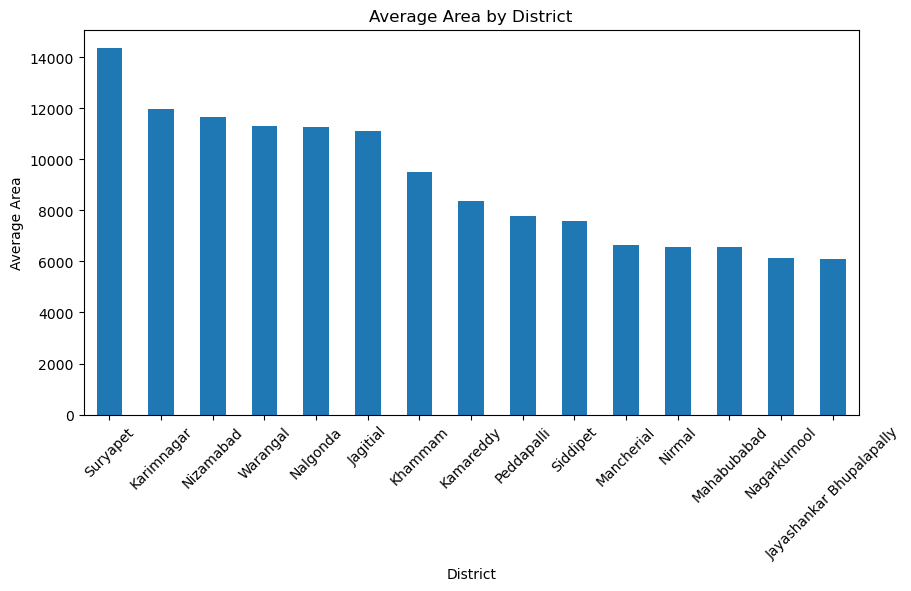

In [39]:
district_area.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Area by District")
plt.xlabel("District")
plt.ylabel("Average Area")
plt.xticks(rotation=45)
plt.show()

In [40]:
## Crop vs Area
crop_area = (
    irrigation.groupby("crop_name")["area"]
    .mean()
    .sort_values(ascending=False)
)

print(crop_area)

crop_name
Rice                         42931.637712
Barley                       15474.584746
Coffee                       15474.584746
Cotton                       15126.775424
Maize                         9817.720339
Groundnut                     4929.728814
Rapeseed and Mustard          4921.983051
Jute                          4652.025424
Linseed                       4652.025424
Bajra                         2941.796610
Sugarcane                     2055.046610
Jowar                         1833.734463
Gram                          1504.796610
Sanhemp                       1054.788136
Fodder Crops                   938.186441
Soyabean                       911.995763
Sesamum                        688.279661
Other Non Food Crops           683.457627
Ragi                           635.487288
Other Oilseeds                 608.008475
Other Pulses                   531.572034
Sunflower                      325.466102
Arhar(Tur)                     282.093220
Tea                     

In [41]:
## Season vs Area 
print(
    irrigation.groupby("season")["area"]
    .mean()
    .sort_values(ascending=False)
)

season
Autumn    57047.716102
Summer    12791.787076
Kharif     5375.027719
Rabi       2899.577966
Winter     1054.788136
Name: area, dtype: float64


In [42]:
## Year vs Area
year_area = (
    irrigation.groupby("year")["area"]
    .mean()
)

print(year_area)

year
2014-2015    9441.163889
2015-2016    8052.555556
2016-2017    5438.578333
2017-2018    5624.926667
2018-2019    5507.480000
2019-2020    6574.705469
2020-2021    7276.307813
2021-2022    7109.163281
2022-2023    7861.603125
Name: area, dtype: float64


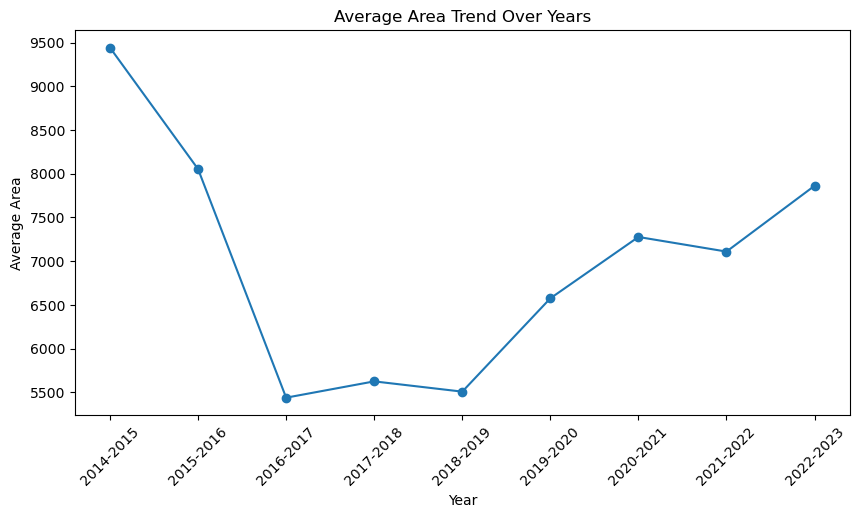

In [43]:
year_area.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Average Area Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Area")
plt.xticks(rotation=45)
plt.show()

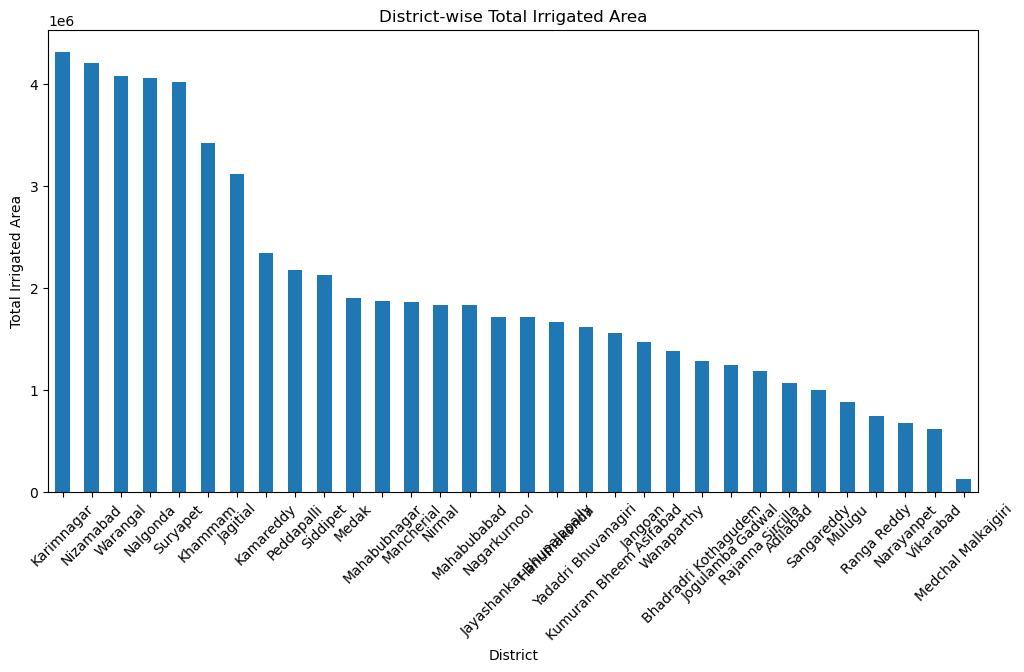

In [44]:
district_area = (
    irrigation.groupby("district_name")["area"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

district_area.plot(kind="bar")

plt.title("District-wise Total Irrigated Area")
plt.xlabel("District")
plt.ylabel("Total Irrigated Area")
plt.xticks(rotation=45)
plt.show()


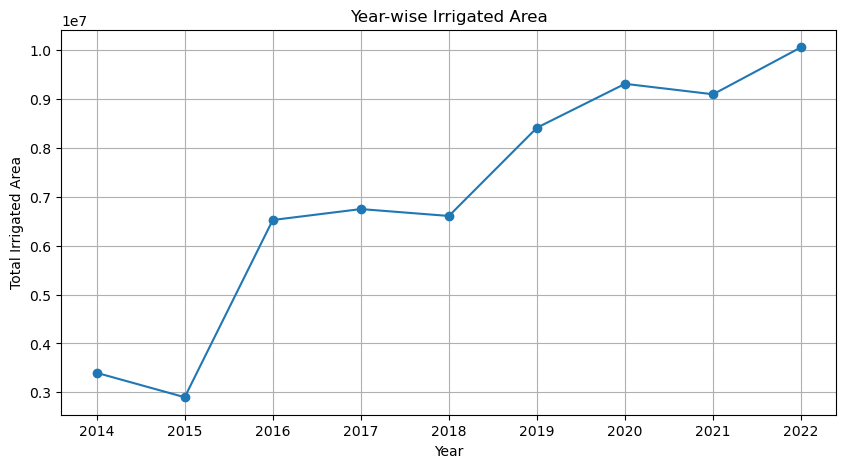

In [45]:
## Year-wise Irrigated Area
year_area = (
    irrigation.groupby("year_start")["area"]
    .sum()
)

plt.figure(figsize=(10, 5))

year_area.plot(
    kind="line",
    marker="o"
)

plt.title("Year-wise Irrigated Area")
plt.xlabel("Year")
plt.ylabel("Total Irrigated Area")
plt.grid()
plt.show()

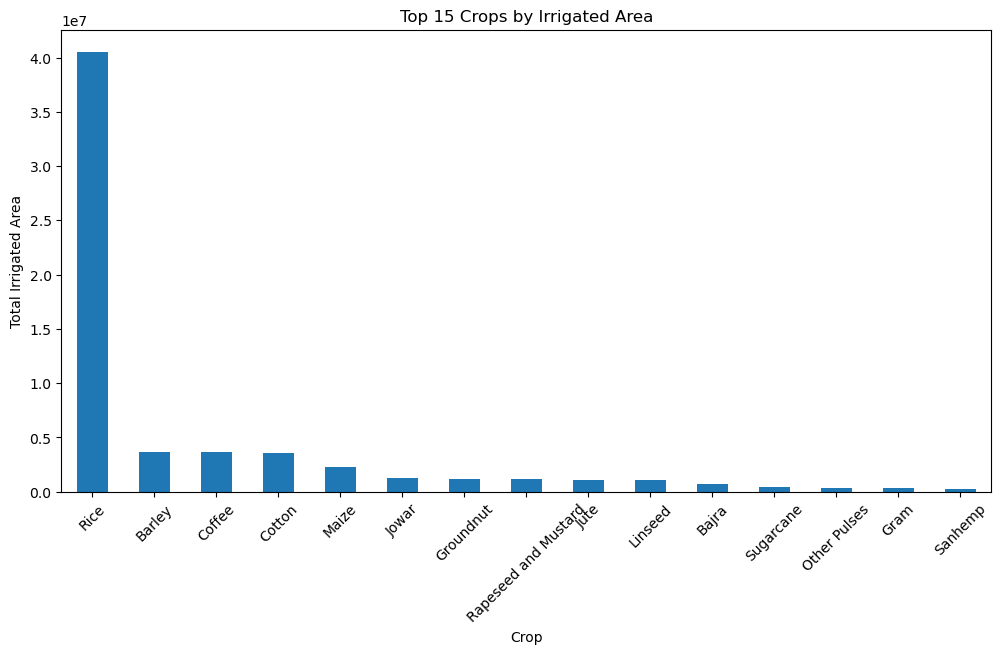

In [46]:
crop_area = (
    irrigation.groupby("crop_name")["area"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

crop_area.plot(kind="bar")

plt.title("Top 15 Crops by Irrigated Area")
plt.xlabel("Crop")
plt.ylabel("Total Irrigated Area")
plt.xticks(rotation=45)
plt.show()

## Multivariate Ana;ysis 

In [47]:
## District + Crop + Area
district_crop_area = (
    irrigation.groupby(
        ["district_name", "crop_name"]
    )["area"]
    .mean()
    .reset_index()
)

print(district_crop_area.head(20))

   district_name                  crop_name          area
0       Adilabad                 Arhar(Tur)   1948.777778
1       Adilabad                      Bajra    897.666667
2       Adilabad                     Barley  11921.000000
3       Adilabad                     Coffee  11921.000000
4       Adilabad                     Cotton  26695.666667
5       Adilabad               Fodder Crops    128.111111
6       Adilabad                       Gram  22917.000000
7       Adilabad                  Groundnut    868.333333
8       Adilabad                      Jowar   2406.259259
9       Adilabad                       Jute      0.000000
10      Adilabad                    Linseed      0.000000
11      Adilabad                      Maize   5974.333333
12      Adilabad                      Mesta      0.000000
13      Adilabad  Other Cereals and Millets      0.407407
14      Adilabad               Other Fibres      0.000000
15      Adilabad           Other Food Crops      0.000000
16      Adilab

In [48]:
## District + Season + Area
district_season_area = (
    irrigation.groupby(
        ["district_name", "season"]
    )["area"]
    .mean()
    .reset_index()
)

print(district_season_area.head(20))

           district_name  season          area
0               Adilabad  Autumn   8073.333333
1               Adilabad  Kharif   2460.712963
2               Adilabad    Rabi   4458.700000
3               Adilabad  Summer    824.361111
4               Adilabad  Winter   3798.000000
5   Bhadradri Kothagudem  Autumn  52263.142857
6   Bhadradri Kothagudem  Kharif   4225.869048
7   Bhadradri Kothagudem    Rabi    816.971429
8   Bhadradri Kothagudem  Summer   5216.678571
9   Bhadradri Kothagudem  Winter      9.000000
10           Hanumakonda  Autumn  33496.142857
11           Hanumakonda  Kharif   4940.000000
12           Hanumakonda    Rabi   3668.871429
13           Hanumakonda  Summer  12428.214286
14           Hanumakonda  Winter      8.000000
15              Jagitial  Autumn  84187.000000
16              Jagitial  Kharif   8337.708333
17              Jagitial    Rabi   3802.200000
18              Jagitial  Summer  28866.178571
19              Jagitial  Winter   7536.000000


In [49]:
## Crop + Season + Year + Area
crop_season_year_area = (
    irrigation.groupby(
        ["crop_name", "season", "year"]
    )["area"]
    .mean()
    .reset_index()
)

print(crop_season_year_area.head(20))

     crop_name  season       year          area
0   Arhar(Tur)  Kharif  2014-2015     64.666667
1   Arhar(Tur)  Kharif  2015-2016    230.444444
2   Arhar(Tur)  Kharif  2016-2017    101.200000
3   Arhar(Tur)  Kharif  2017-2018     97.966667
4   Arhar(Tur)  Kharif  2018-2019    247.066667
5   Arhar(Tur)  Kharif  2019-2020    413.593750
6   Arhar(Tur)  Kharif  2020-2021    436.312500
7   Arhar(Tur)  Kharif  2021-2022    403.875000
8   Arhar(Tur)  Kharif  2022-2023    325.312500
9        Bajra  Kharif  2014-2015   1013.555556
10       Bajra  Kharif  2015-2016    474.000000
11       Bajra  Kharif  2016-2017   3486.266667
12       Bajra  Kharif  2017-2018   3295.033333
13       Bajra  Kharif  2018-2019   3283.800000
14       Bajra  Kharif  2019-2020   3051.843750
15       Bajra  Kharif  2020-2021   3053.312500
16       Bajra  Kharif  2021-2022   2889.781250
17       Bajra  Kharif  2022-2023   2846.406250
18      Barley    Rabi  2014-2015  23460.555556
19      Barley    Rabi  2015-2016  23460

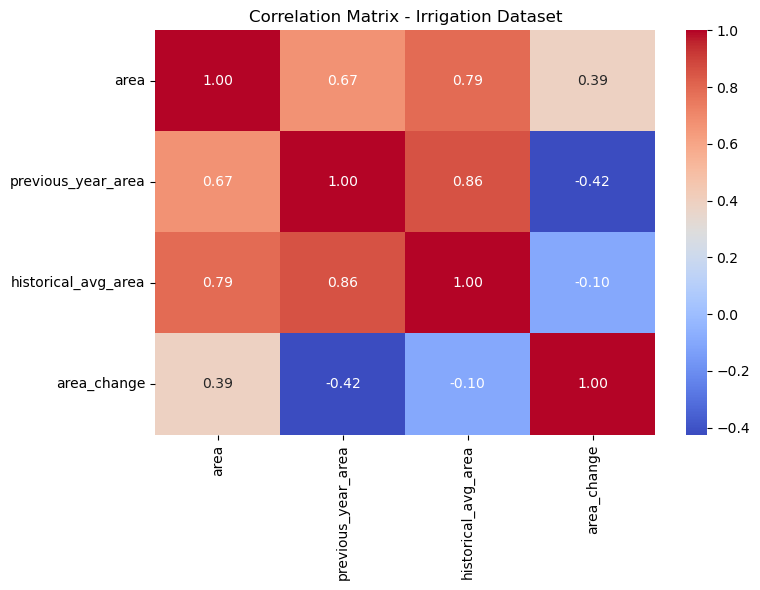

In [53]:
corr_cols = [
    "area",          
    "previous_year_area",  
    "historical_avg_area",             
    "area_change"     
]

corr = irrigation[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - Irrigation Dataset")
plt.tight_layout()
plt.show()



In [54]:
ml_path = r"C:\Users\SVS\Desktop\ML Project\data\ml_ready"

irrigation.to_csv(
    ml_path + r"\Irrigation_Clean.csv",
    index=False
)

print("Irrigation_Clean.csv saved successfully.")

Irrigation_Clean.csv saved successfully.


## Insights 
- Irrigated Area Distribution
Irrigated area has a mean of 6,681.65, while the median is only 26, and the maximum is 225,262.
The large difference between the mean and median shows that most observations have smaller irrigation areas, while a few observations have extremely large areas.
- Crop vs Irrigated Area
 Rice has an average irrigated area of approximately 42,931.64, while Cotton has approximately 15,126.78.
This large difference shows that irrigation coverage varies significantly between crops and is strongly dependent on crop type.
- District-wise Irrigation
  Suryapet has an average irrigated area of approximately 14,372.76, while Medchal Malkajgiri has approximately 456.73.
This large difference indicates that irrigation availability is not uniform across Telangana districts.

SyntaxError: invalid syntax (3950571591.py, line 1)